In [ ]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as py
import seaborn as sns
import matplotlib.ticker as ticker

In [ ]:
dpwh = pd.read_csv("ProjectsFloodControl.csv")

In [ ]:
dpwh.head()

,Index,Region,LegislativeDistrict,Municipality,DistrictEngineeringOffice,ProjectID,ProjectDescription,TypeofWork,FundingYear,ContractID,ABC_String,ContractCost_String,CompletionDateActual,Contractor,StartDate,Latitude,Longitude
0,67,Region I,PANGASINAN (FIRST LEGISLATIVE DISTRICT),CITY OF ALAMINOS (PANGASINAN),Pangasinan 1st District Engineering Office,P00941153LZ,"Rehabilitation of Flood Mitigation Structure, ...",Rehabilitation / Major Repair of Flood Control...,2025,25AG0078,4950000,4850385.71,2025-05-14,GED CONSTRUCTION,02/21/2025,16.096847,119.969155
1,689,Region IV-B,PALAWAN (THIRD LEGISLATIVE DISTRICT),PUERTO PRINCESA CITY (CAPITAL) (PALAWAN),Palawan 3rd District Engineering Office,P00921211LZ,"Construction of Slope Protection Structure, In...",Construction of Flood Mitigation Structure,2025,25EG0013,14700000,14669999.48,2025-05-19,KRATOS STRUCPRIME CONSTRUCTION AND SUPPLY CORP,02/05/2025,9.554140,118.618250
2,916,Region I,PANGASINAN (FIRST LEGISLATIVE DISTRICT),CITY OF ALAMINOS (PANGASINAN),Pangasinan 1st District Engineering Office,P00941152LZ,"Construction of Line Canal, Barangay Quibuar, ...",Construction of Flood Mitigation Structure,2025,25AG0077,4950000,4850666.92,2025-05-21,GED CONSTRUCTION,02/10/2025,16.356031,120.433852
3,1220,Region III,TARLAC (FIRST LEGISLATIVE DISTRICT),CITY OF TARLAC (CAPITAL) (TARLAC),Tarlac District Engineering Office,P00921064LZ,Construction of Slope Protection Structure alo...,Construction of Slope Protection Structure,2025,25CJ0124,14700000,14229719.67,2025-05-22,BIG BERTHA CONSTRUCTION & DEVELOPMENT,01/27/2025,15.427456,120.613964
4,1409,Region III,TARLAC (FIRST LEGISLATIVE DISTRICT),MONCADA (TARLAC),Tarlac District Engineering Office,P00921065LZ,Rehabilitation of Sabo Dam at Camangaan West C...,Rehabilitation / Major Repair of Slope Protect...,2025,25CJ0129,14700000,14700000,2025-04-16,RD8 BUILDERS CORPORATION UNDER THE NAME OF RD8...,01/27/2025,15.716535,120.570923


In [ ]:
dpwh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9855 entries, 0 to 9854
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Index                      9855 non-null   int64  
 1   Region                     9855 non-null   object 
 2   LegislativeDistrict        9855 non-null   object 
 3   Municipality               9189 non-null   object 
 4   DistrictEngineeringOffice  9855 non-null   object 
 5   ProjectID                  9855 non-null   object 
 6   ProjectDescription         9855 non-null   object 
 7   TypeofWork                 9855 non-null   object 
 8   FundingYear                9855 non-null   int64  
 9   ContractID                 9855 non-null   object 
 10  ABC_String                 9855 non-null   object 
 11  ContractCost_String        9855 non-null   object 
 12  CompletionDateActual       9855 non-null   object 
 13  Contractor                 9855 non-null   objec

In [ ]:
dpwh.shape

(9855, 17)

In [ ]:
dpwh.isnull().sum()

,0
Index,0
Region,0
LegislativeDistrict,0
Municipality,666
DistrictEngineeringOffice,0
ProjectID,0
ProjectDescription,0
TypeofWork,0
FundingYear,0
ContractID,0


In [ ]:
dpwh.duplicated().sum()

np.int64(0)

In [ ]:
dp = dpwh[['Region','Municipality','DistrictEngineeringOffice','ProjectID','ProjectDescription','TypeofWork','Contractor','ContractID','ContractCost_String']].copy()

In [ ]:
dp['Municipality'] = dp['Municipality'].fillna('Not Specified')

In [ ]:
dp['ContractCost'] = pd.to_numeric(dp['ContractCost_String'], errors = 'coerce')

In [ ]:
print(dp['Region'].value_counts().head(5))

Region
Region III                 1617
National Capital Region    1058
Region V                    866
Region I                    851
Region IV-A                 829
Name: count, dtype: int64


In [ ]:
print(dp.isnull().sum())

Region                        0
Municipality                  0
DistrictEngineeringOffice     0
ProjectID                     0
ProjectDescription            0
TypeofWork                    0
Contractor                    0
ContractID                    0
ContractCost_String           0
ContractCost                 28
dtype: int64


In [ ]:
dp = dp.dropna(subset=['ContractCost'])

In [ ]:
print(dp.isnull().sum())

Region                       0
Municipality                 0
DistrictEngineeringOffice    0
ProjectID                    0
ProjectDescription           0
TypeofWork                   0
Contractor                   0
ContractID                   0
ContractCost_String          0
ContractCost                 0
dtype: int64


In [ ]:
print(dp['Contractor'].value_counts().head(10))

Contractor
LEGACY CONSTRUCTION CORPORATION (FORMERLY: LEGACY CONSTRUCTION)             114
QM BUILDERS                                                                  88
ALPHA & OMEGA GEN. CONTRACTOR & DEVELOPMENT CORP.                            84
ST. TIMOTHY CONSTRUCTION CORPORATION                                         83
SUNWEST, INC. (FORMERLY: SUNWEST CONSTRUCTION & DEVELOPMENT CORPORATION)     67
CENTERWAYS CONSTRUCTION AND DEVELOPMENT INC.                                 63
TRIPLE 8 CONSTRUCTION & SUPPLY, INC. (FORMERLY TRIPLE 8 CONST. & SUPPLY)     57
ROYAL CROWN MONARCH CONSTRUCTION & SUPPLIES CORP.                            56
WAWAO BUILDERS                                                               53
L.R. TIQUI BUILDERS, INC.                                                    52
Name: count, dtype: int64


In [ ]:
print(dp['TypeofWork'].value_counts().head(10))

TypeofWork
Construction of Flood Mitigation Structure                     6343
Construction of Slope Protection Structure                      739
Construction of Revetment                                       733
Construction of Drainage Structure                              678
Rehabilitation / Major Repair of Flood Control Structure        646
Construction of Dike                                            224
Rehabilitation / Major Repair of Drainage Structure             215
Construction of Flood Mitigation Facility                       169
Rehabilitation / Major Repair of Slope Protection Structure      41
Construction of Groundsill                                       12
Name: count, dtype: int64


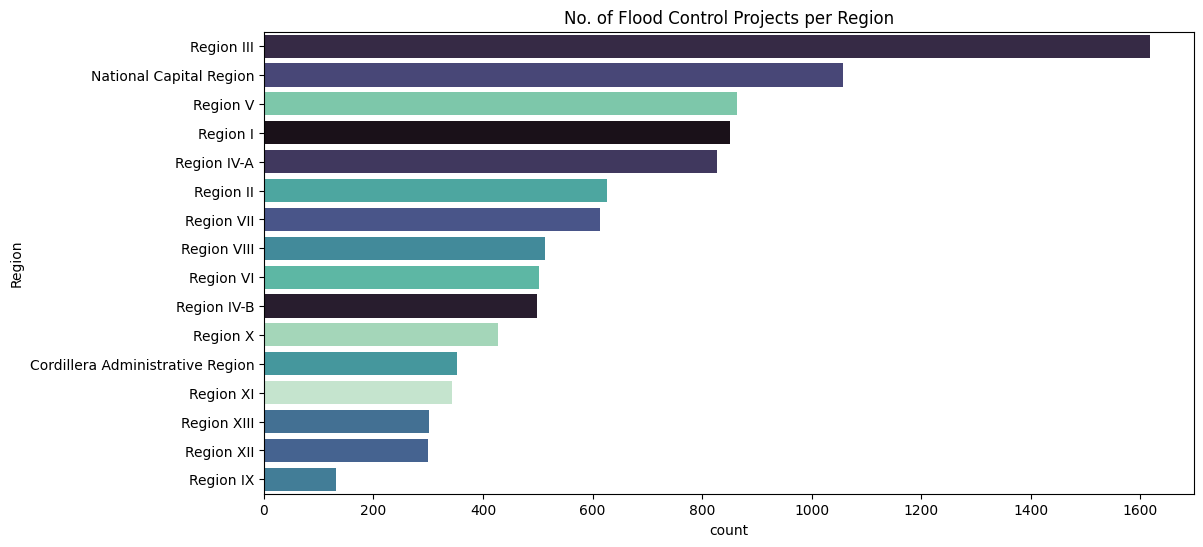

In [ ]:
fig = py.subplots(figsize=(12, 6))
sns.countplot(data=dp,y='Region' ,order=dp['Region'].value_counts().index,hue='Region', palette='mako', legend=False)
py.title('No. of Flood Control Projects per Region')
py.show()

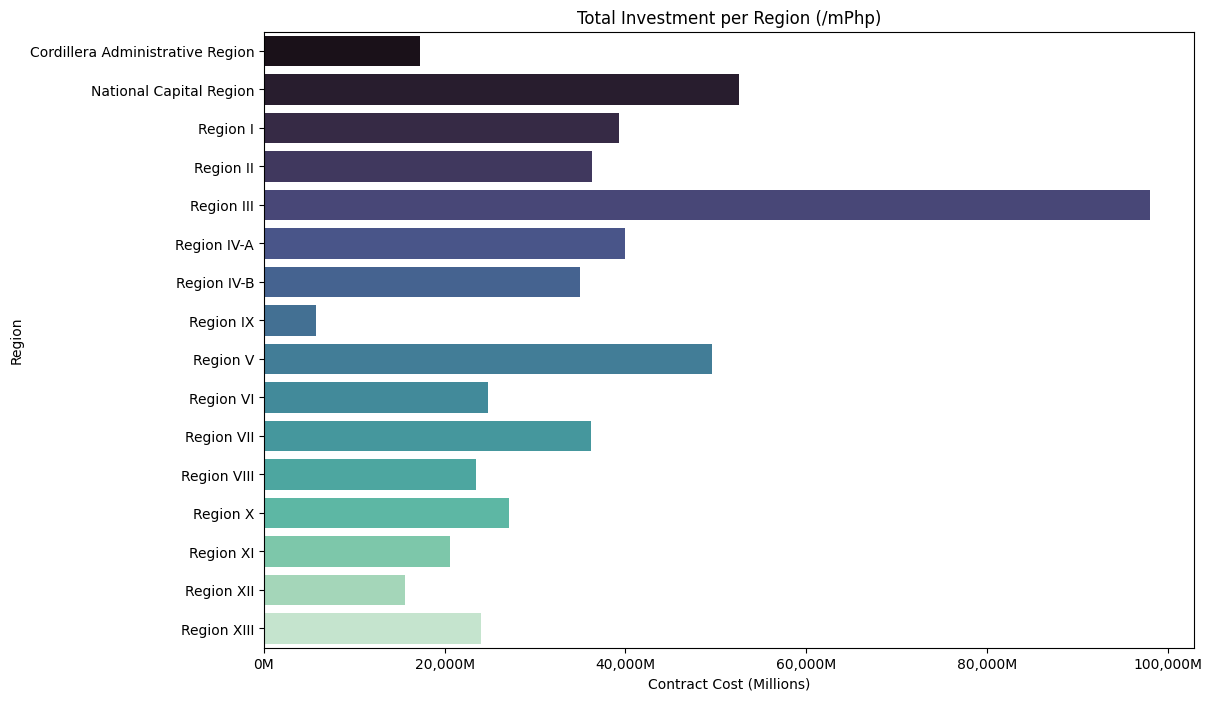

In [ ]:
fig, ax = py.subplots(figsize=(12, 8))

region_spending = dp.groupby('Region')['ContractCost'].sum().reset_index()

sns.barplot(data=region_spending,x='ContractCost',y='Region',hue='Region',palette='mako',legend=False,ax=ax)

# format convert num to M
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:,.0f}M'))

py.title('Total Investment per Region (/mPhp)')
py.xlabel('Contract Cost (Millions)')
py.show()

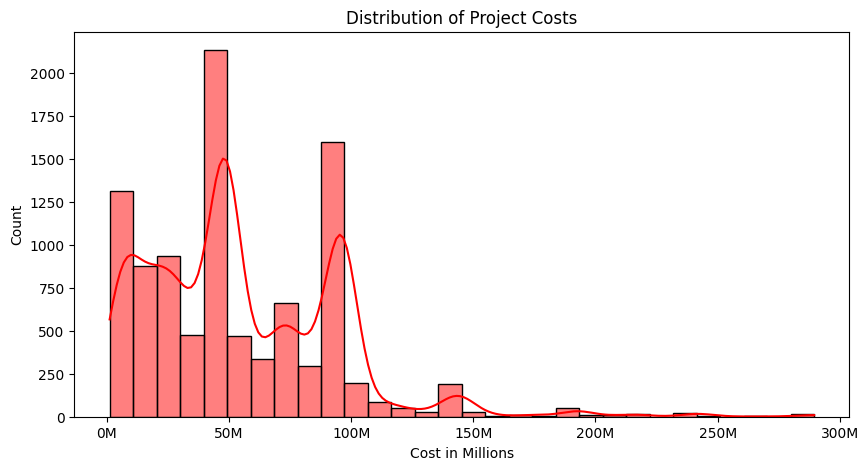

In [ ]:
fig, ax = py.subplots(figsize=(10, 5))

sns.histplot(dp['ContractCost'], bins=30, kde=True, ax=ax, color='red')

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:,.0f}M'))

py.title('Distribution of Project Costs')
py.xlabel('Cost in Millions')
py.show()

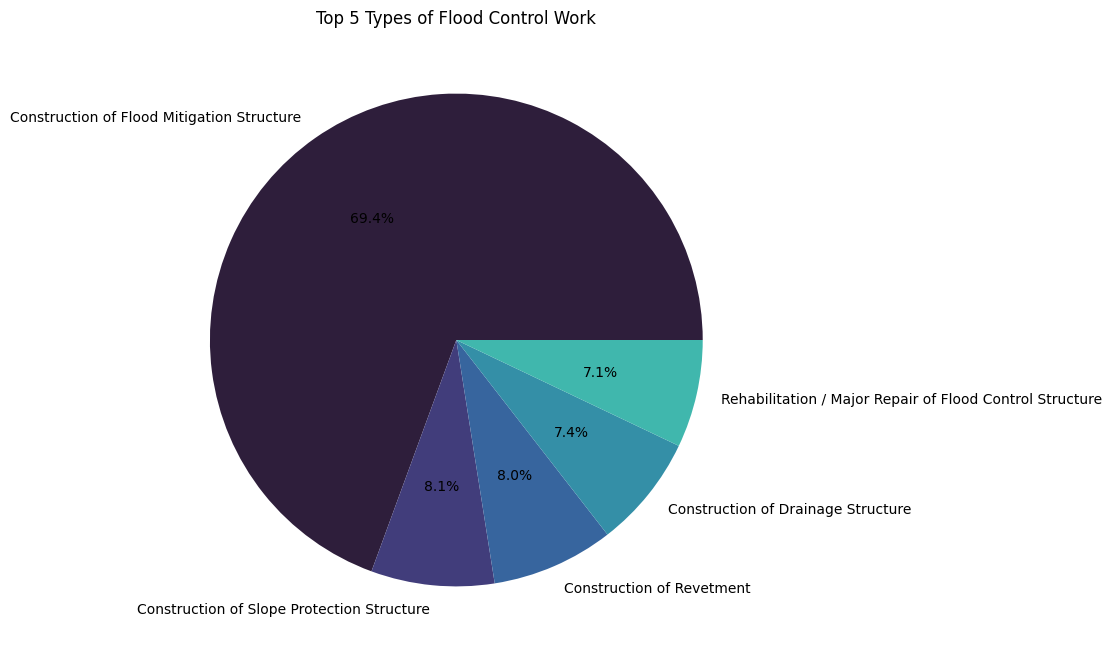

In [ ]:
py.figure(figsize=(8, 8))
work_types = dp['TypeofWork'].value_counts().head(5)

py.pie(work_types, labels=work_types.index, autopct='%1.1f%%', colors=sns.color_palette('mako'))
py.title('Top 5 Types of Flood Control Work')
py.show()

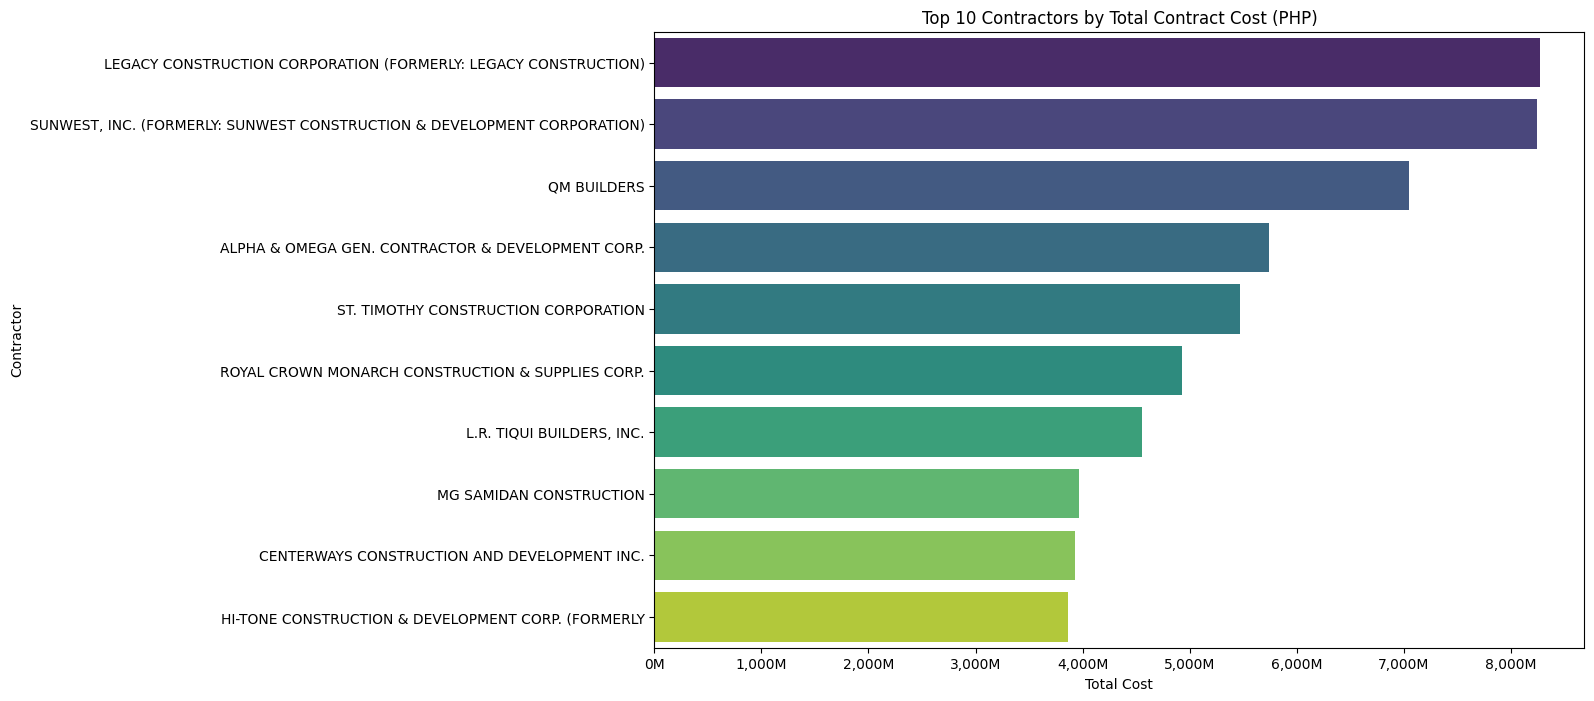

In [ ]:
contractor_spending = dp.groupby('Contractor')['ContractCost'].sum().nlargest(10).reset_index()

fig, ax = py.subplots(figsize=(12, 8))

sns.barplot(data=contractor_spending,x='ContractCost',y='Contractor',hue='Contractor',palette='viridis',legend=False,ax=ax)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:,.0f}M'))

py.title('Top 10 Contractors by Total Contract Cost (PHP)')
py.xlabel('Total Cost')
py.show()

In [ ]:
dp.to_csv('Flood.csv', index=False)